# Heart Disease Prediction 
Dataset: Cleveland Heart Disease Database  
Target: `target` (1 = disease, 0 = no disease)

## 1 · Imports & Data Load

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import joblib, json

df = pd.read_csv("../data/heart.csv")
df.columns = df.columns.str.lstrip('\ufeff')  # strip BOM
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
df.info()
print(df.isnull().sum())
print('\nTarget balance:')
print(df['target'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target balance:
targ

## 2 · EDA

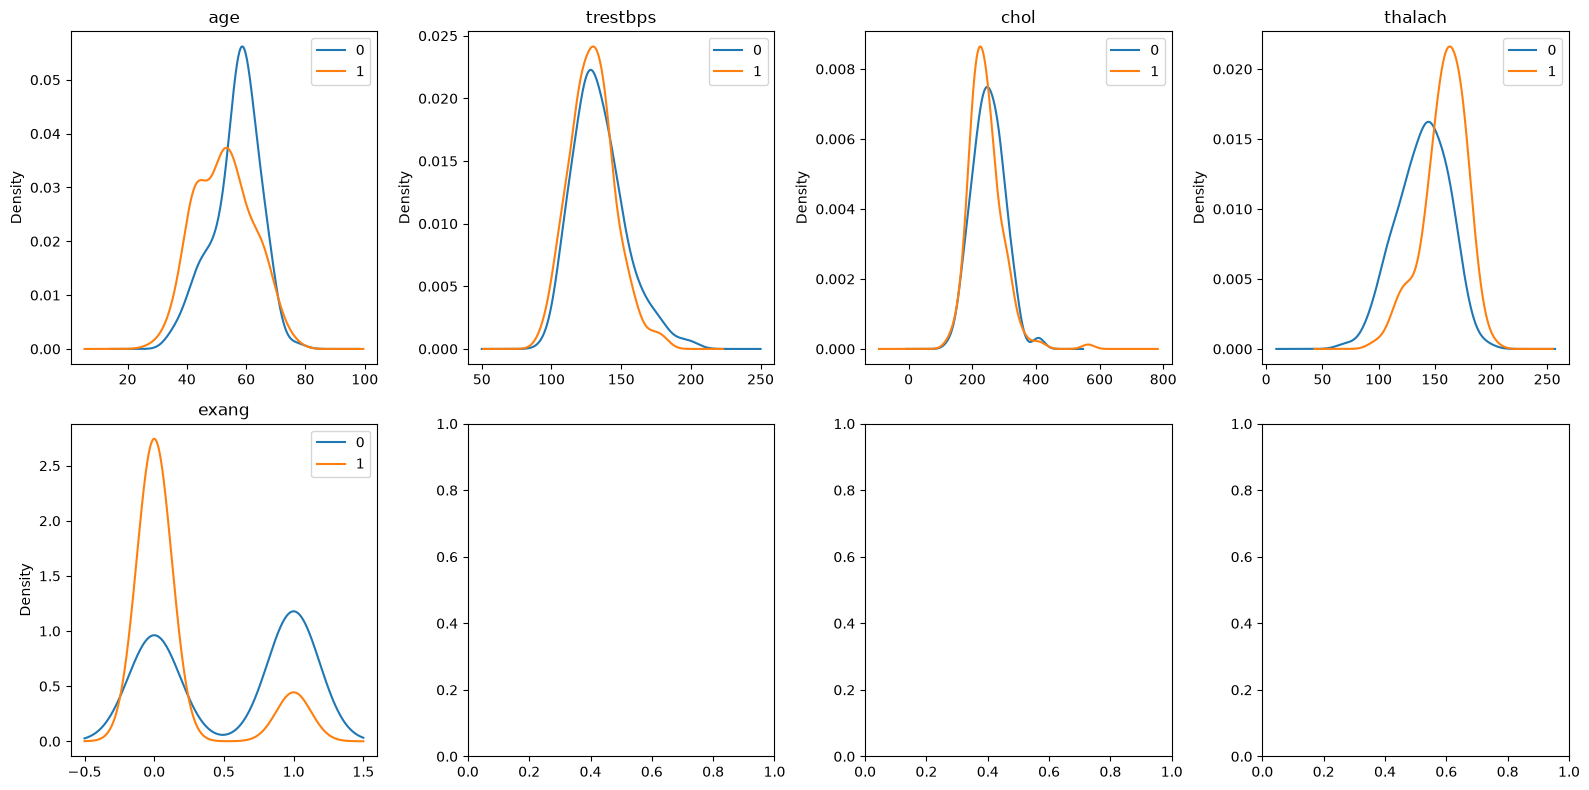

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16,8))
num_cols = ['age','trestbps','chol','thalach','oldpeak']
for i, col in enumerate(['age','trestbps','chol','thalach','exang']):
    ax = axes[i//4][i%4]
    df.groupby('target')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
plt.tight_layout(); plt.show()

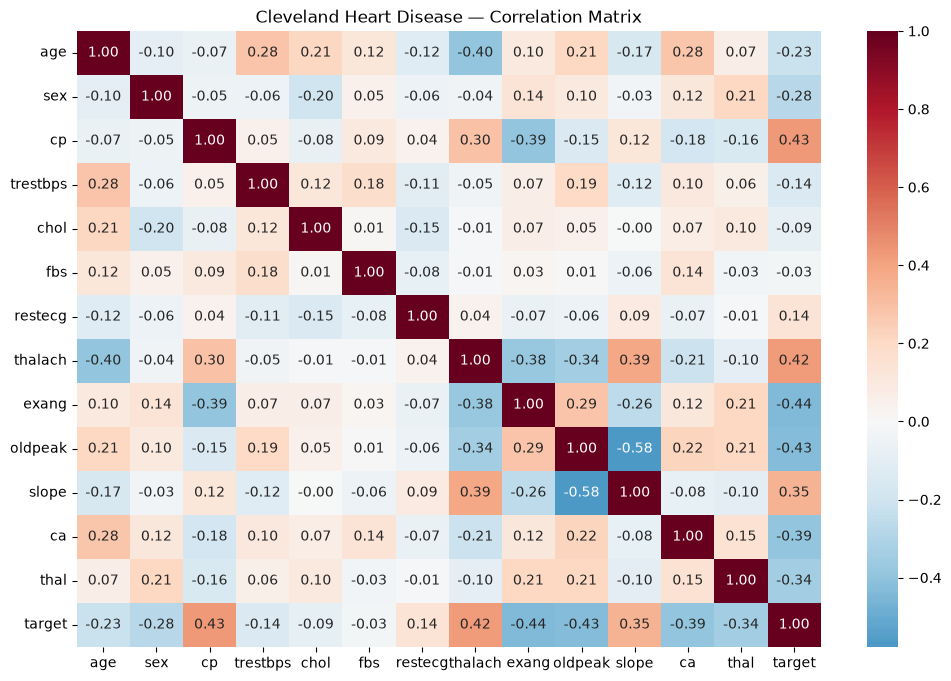

In [4]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title("Cleveland Heart Disease — Correlation Matrix"); plt.show()

## 3 · Feature Engineering & Field Mapping


In [5]:
df['family_history'] = 0
df['smoker']         = 0

FEATURES = ['age','chol','trestbps','thalach','exang','family_history','smoker']
X = df[FEATURES].rename(columns={'chol':'cholesterol','trestbps':'blood_pressure',
                                  'thalach':'max_heart_rate','exang':'exercise_angina'})
y = df['target']
print(X.head())

   age  cholesterol  blood_pressure  max_heart_rate  exercise_angina  \
0   63          233             145             150                0   
1   37          250             130             187                0   
2   41          204             130             172                0   
3   56          236             120             178                0   
4   57          354             120             163                1   

   family_history  smoker  
0               0       0  
1               0       0  
2               0       0  
3               0       0  
4               0       0  


## 4 · Preprocessing  
## 5 · Train / Test Split 

In [6]:
def make_pipe(clf):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()), ('clf', clf)])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (242, 7), Test: (61, 7)


## 6 · Model Training & Comparison

In [9]:
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':            XGBClassifier(n_estimators=200, random_state=42,
                                        eval_metric='logloss', verbosity=0),
}
results = {}; pipes = {}
for name, clf in candidates.items():
    p = make_pipe(clf); p.fit(X_train, y_train)
    yp  = p.predict(X_test)
    ypr = p.predict_proba(X_test)[:,1]
    results[name] = {'accuracy':  round(accuracy_score(y_test,yp),4),
                     'precision': round(precision_score(y_test,yp),4),
                     'recall':    round(recall_score(y_test,yp),4),
                     'f1':        round(f1_score(y_test,yp),4),
                     'roc_auc':   round(roc_auc_score(y_test,ypr),4)}
    pipes[name] = p
pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.7049,0.6923,0.8182,0.7500,0.7684
RandomForest,0.7049,0.7143,0.7576,0.7353,0.7652
XGBoost,0.6721,0.6970,0.6970,0.6970,0.7089


## 7 · Evaluation

Best: LogisticRegression


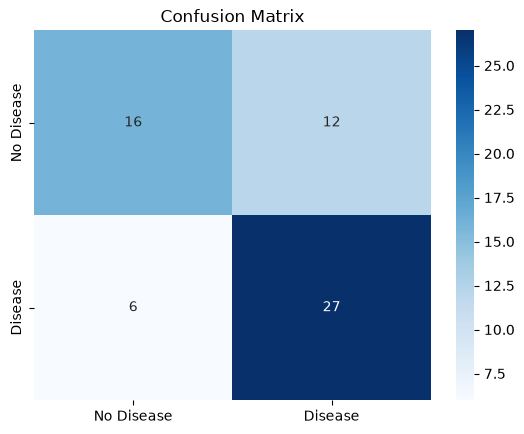

              precision    recall  f1-score   support

  No Disease       0.73      0.57      0.64        28
     Disease       0.69      0.82      0.75        33

    accuracy                           0.70        61
   macro avg       0.71      0.69      0.70        61
weighted avg       0.71      0.70      0.70        61



In [10]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = pipes[best_name]
print(f"Best: {best_name}")
y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
plt.title('Confusion Matrix'); plt.show()
print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))

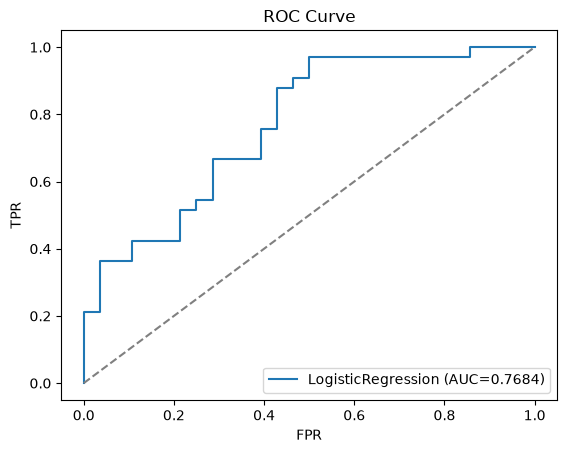

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{best_name} (AUC={results[best_name]["roc_auc"]})')
plt.plot([0,1],[0,1],'--',color='grey'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend(); plt.show()

## 8 · Save Model & Metrics

In [14]:
joblib.dump(best, '../models/heart_model.joblib')
metrics = {**results[best_name], 'model': best_name,
           'features': list(X.columns), 'test_size': 0.2, 'random_state': 42}
with open('../metrics/heart_metrics.json','w') as f: json.dump(metrics,f,indent=2)